In [1]:
import duckdb
import os
from pathlib import Path

In [2]:
# Connect to SQLStorm database
db_path = Path(os.path.abspath('')).parent / "workload/adversarial-benchmark/sqlstorm.duckdb"
con = duckdb.connect(str(db_path))
all_tables = con.sql("select table_name from information_schema.tables").df()["table_name"].to_list()
print(f"Connected to database: {db_path}")
print(f"Tables: {all_tables}")


Connected to database: /home/jtao/phd/bayes-lqo/bayes_lqo/workload/adversarial-benchmark/sqlstorm.duckdb
Tables: ['Badges', 'CloseReasonTypes', 'Comments', 'LinkTypes', 'PostHistory', 'PostHistoryTypes', 'PostLinks', 'Posts', 'PostTypes', 'Tags', 'Users', 'Votes', 'VoteTypes']


In [3]:
#TODO support compound primary keys

primary_keys = con.sql("""
SELECT tc.table_name, c.column_name
FROM information_schema.table_constraints tc,
     information_schema.constraint_column_usage ccu,
     information_schema.columns as c
WHERE tc.constraint_schema = ccu.constraint_schema
  AND tc.constraint_name = ccu.constraint_name
  AND c.table_schema = tc.constraint_schema
  AND tc.table_name = c.table_name 
  AND ccu.column_name = c.column_name
  AND tc.constraint_type = 'PRIMARY KEY';
""").df().set_index("table_name").to_dict()["column_name"]
primary_keys


{'Badges': 'Id',
 'CloseReasonTypes': 'Id',
 'Comments': 'Id',
 'LinkTypes': 'Id',
 'PostHistory': 'Id',
 'PostHistoryTypes': 'Id',
 'PostLinks': 'Id',
 'PostTypes': 'Id',
 'Posts': 'Id',
 'Tags': 'Id',
 'Users': 'Id',
 'VoteTypes': 'Id',
 'Votes': 'Id'}

In [4]:
import json

schema_json_path = Path(os.path.abspath('')).parent / "workload/adversarial-benchmark/sqlstorm.dbschema.json"

with open(schema_json_path, 'r') as f:
    schema_data = json.load(f)

foreign_keys = []
for table in schema_data['tables']:
    table_name = table['name']
    if 'foreign keys' in table:
        for fk in table['foreign keys']:
            fk_column = fk['column']
            ref_table = fk['foreign table']
            ref_column = fk['foreign column']
            join_predicate = f"{table_name}.{fk_column} = {ref_table}.{ref_column}"
            foreign_keys.append((table_name, ref_table, join_predicate))

foreign_keys


[('Badges', 'Users', 'Badges.UserId = Users.Id'),
 ('Posts', 'PostTypes', 'Posts.PostTypeId = PostTypes.Id'),
 ('Posts', 'Posts', 'Posts.AcceptedAnswerId = Posts.Id'),
 ('Posts', 'Posts', 'Posts.ParentId = Posts.Id'),
 ('Posts', 'Users', 'Posts.OwnerUserId = Users.Id'),
 ('Posts', 'Users', 'Posts.LastEditorUserId = Users.Id'),
 ('Comments', 'Posts', 'Comments.PostId = Posts.Id'),
 ('Comments', 'Users', 'Comments.UserId = Users.Id'),
 ('PostHistory',
  'PostHistoryTypes',
  'PostHistory.PostHistoryTypeId = PostHistoryTypes.Id'),
 ('PostHistory', 'Posts', 'PostHistory.PostId = Posts.Id'),
 ('PostHistory', 'Users', 'PostHistory.UserId = Users.Id'),
 ('PostLinks', 'Posts', 'PostLinks.PostId = Posts.Id'),
 ('PostLinks', 'Posts', 'PostLinks.RelatedPostId = Posts.Id'),
 ('PostLinks', 'LinkTypes', 'PostLinks.LinkTypeId = LinkTypes.Id'),
 ('Tags', 'Posts', 'Tags.ExcerptPostId = Posts.Id'),
 ('Tags', 'Posts', 'Tags.WikiPostId = Posts.Id'),
 ('Votes', 'VoteTypes', 'Votes.VoteTypeId = VoteTypes.Id

/tmp/ipykernel_99299/1049425101.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


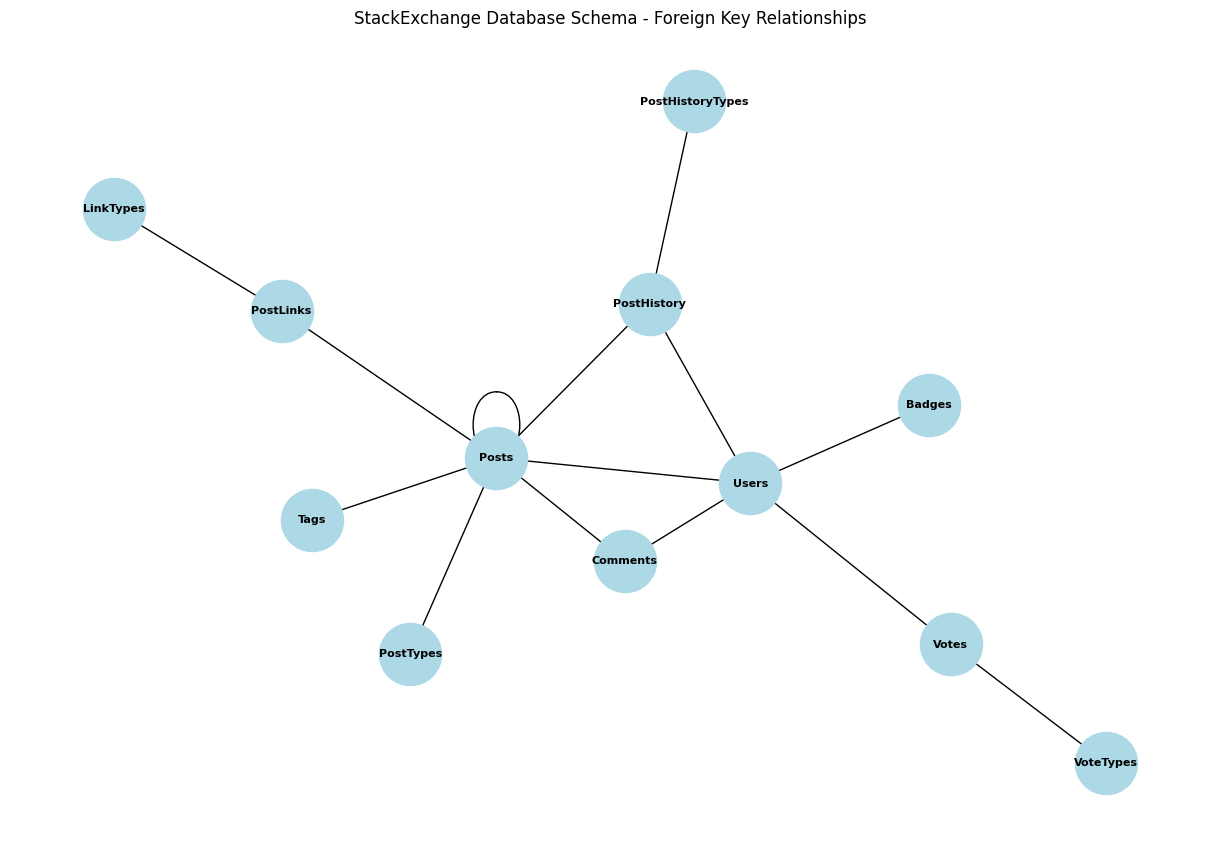

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for s, d, w in foreign_keys:
    G.add_edge(s, d, label=w)

plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=8, font_weight='bold')
plt.title("StackExchange Database Schema - Foreign Key Relationships")
plt.tight_layout()
plt.show()


/tmp/ipykernel_99299/3289334248.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


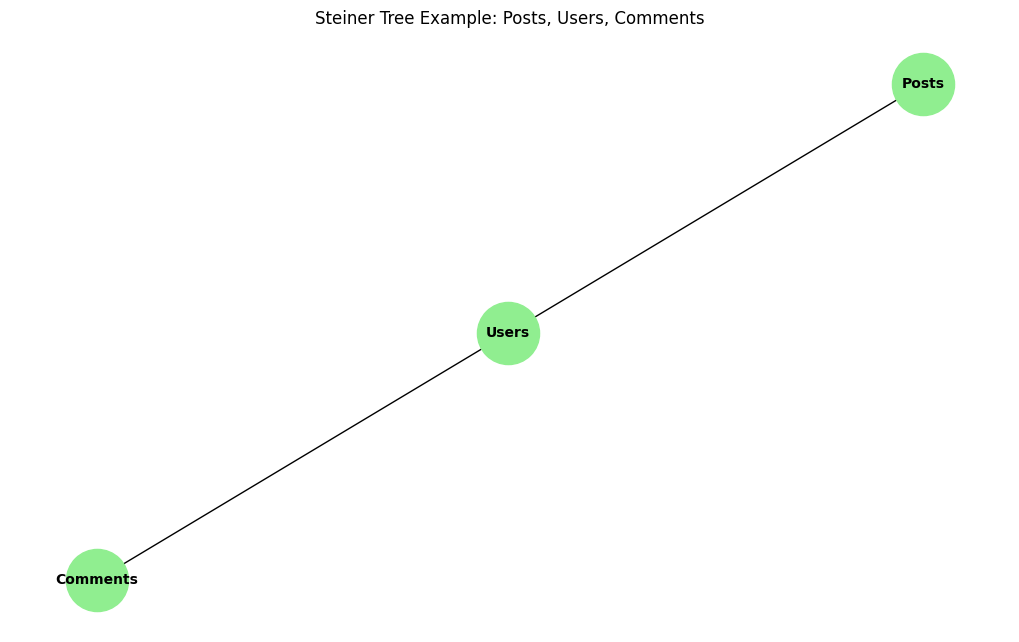

In [6]:
from networkx.algorithms import approximation
result = approximation.steiner_tree(G, ["Posts", "Users", "Comments"])
plt.figure(figsize=(10, 6))
nx.draw(result, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold')
plt.title("Steiner Tree Example: Posts, Users, Comments")
plt.tight_layout()
plt.show()


In [7]:
con.sql("select column_name, column_type from (describe Posts) where key is null")


┌───────────────────────┬─────────────┐
│      column_name      │ column_type │
│        varchar        │   varchar   │
├───────────────────────┼─────────────┤
│ PostTypeId            │ SMALLINT    │
│ AcceptedAnswerId      │ INTEGER     │
│ ParentId              │ INTEGER     │
│ CreationDate          │ TIMESTAMP   │
│ Score                 │ INTEGER     │
│ ViewCount             │ INTEGER     │
│ Body                  │ VARCHAR     │
│ OwnerUserId           │ INTEGER     │
│ OwnerDisplayName      │ VARCHAR     │
│ LastEditorUserId      │ INTEGER     │
│ LastEditorDisplayName │ VARCHAR     │
│ LastEditDate          │ TIMESTAMP   │
│ LastActivityDate      │ TIMESTAMP   │
│ Title                 │ VARCHAR     │
│ Tags                  │ VARCHAR     │
│ AnswerCount           │ INTEGER     │
│ CommentCount          │ INTEGER     │
│ FavoriteCount         │ INTEGER     │
│ ClosedDate            │ TIMESTAMP   │
│ CommunityOwnedDate    │ TIMESTAMP   │
│ ContentLicense        │ VARCHAR     │


In [8]:
con.sql("select Score, count(*) cnt from Posts group by Score order by cnt desc limit 10")


┌───────┬──────────┐
│ Score │   cnt    │
│ int32 │  int64   │
├───────┼──────────┤
│     0 │ 24733873 │
│     1 │ 14651021 │
│     2 │  6861746 │
│     3 │  3493507 │
│     4 │  1972299 │
│    -1 │  1623418 │
│     5 │  1222695 │
│     6 │   823062 │
│     7 │   582229 │
│    -2 │   503385 │
├───────┴──────────┤
│     10 rows      │
└──────────────────┘

In [9]:
import json
string_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "filter": { "type": "string", "enum": ["random", "most_popular", "least_popular"] }
    },
    "required": ["column", "filter"],
    "additionalProperties": false
}
"""

int_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "op": { "type": "string", "enum": ["<", ">", "=", "!="] },
      "value": { "anyOf": [
          { "type": "number", "minimum": 0.0, "maximum": 1.0 },
          { "type": "string", "enum": ["most_popular", "least_popular"] }
      ]}
    },
    "required": ["column", "op", "value"],
    "additionalProperties": false
}
"""

table_schema = """
{
    "type": "object",
    "properties": {
        "table": { "type": "string", "const": "TABLE_NAME" },
        "filters": {
            "type": "array",
            "items": { "anyOf": COLUMN_SCHEMAS }
        }
    },
    "required": ["table"],
    "additionalProperties": false
}
"""
from jsonschema import validate


In [10]:
score_schema = json.loads(int_col_schema.replace("COL_NAME", "Score"))
validate(instance={"column": "Score", "op": "!=", "value": "most_popular"}, schema=score_schema)


In [11]:
cols = con.sql("select column_name, column_type from (describe Posts) where key is null").df()
col_schema = []
for _, d in cols.iterrows():
    cname = d["column_name"]
    ctype = d["column_type"]

    if "VARCHAR" in str(ctype) or "TEXT" in str(ctype):
        col_schema.append(json.loads(string_col_schema.replace("COL_NAME", cname)))
    elif "INTEGER" in str(ctype) or "SMALLINT" in str(ctype) or "BIGINT" in str(ctype):
        col_schema.append(json.loads(int_col_schema.replace("COL_NAME", cname)))

col_schema = json.dumps(col_schema)
posts_schema = table_schema.replace("TABLE_NAME", "Posts").replace("COLUMN_SCHEMAS", col_schema)
posts_schema = json.loads(posts_schema)


In [12]:
def string_column_analysis():
    # Analyze string column cardinality to identify high-cardinality columns
    # that would be too expensive to compute most_popular/random for
    print("Analyzing string column cardinality...")
    print("=" * 80)

    high_cardinality_threshold = 0.9  # If distinct_count/total_count > 0.9, column is too unique

    string_column_stats = []
    for table in all_tables:
        cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
        
        for _, col_row in cols.iterrows():
            cname = col_row['column_name']
            ctype = str(col_row['column_type'])
            
            # Skip ID columns
            if cname.endswith('Id') or cname.endswith('_id'):
                continue
                
            # Only analyze string columns
            if "VARCHAR" in ctype or "TEXT" in ctype:
                # Get count and distinct count
                result = con.sql(f"""
                    SELECT 
                        COUNT(*) as total_count,
                        approx_count_distinct({cname}) as distinct_count
                    FROM {table}
                """).df()
                
                total_count = result['total_count'].iloc[0]
                distinct_count = result['distinct_count'].iloc[0]
                
                if total_count > 0:
                    uniqueness_ratio = distinct_count / total_count
                else:
                    uniqueness_ratio = 0
                
                string_column_stats.append({
                    'table': table,
                    'column': cname,
                    'total_count': total_count,
                    'distinct_count': distinct_count,
                    'uniqueness_ratio': uniqueness_ratio,
                    'too_unique': uniqueness_ratio > high_cardinality_threshold
                })

    # Sort by uniqueness ratio descending
    string_column_stats.sort(key=lambda x: x['uniqueness_ratio'], reverse=True)

    # Display results
    import pandas as pd
    df_stats = pd.DataFrame(string_column_stats)
    print(df_stats.to_string(index=False))

    print("\n" + "=" * 80)
    print("High-cardinality columns to filter out (uniqueness > 90%):")
    print("=" * 80)
    high_cardinality_cols = [(row['table'], row['column']) for row in string_column_stats if row['too_unique']]
    for table, col in high_cardinality_cols:
        print(f"  {table}.{col}")
        
    print(f"\nTotal high-cardinality columns: {len(high_cardinality_cols)}")

# This is expensive, commented out to avoid when rerunning the notebook
# string_column_analysis()

In [13]:
def analyze_all_null_columns():
    # Analyze columns that are entirely NULL
    print("Analyzing columns with all NULL values...")
    print("=" * 80)
    
    con.sql("SET memory_limit='32GB'")
    
    all_null_columns = []
    for table in all_tables:
        cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
        
        for _, col_row in cols.iterrows():
            cname = col_row['column_name']
            ctype = str(col_row['column_type'])
            
            # Skip ID columns
            if cname.endswith('Id') or cname.endswith('_id'):
                continue
            
            # Check if column has any non-NULL values
            result = con.sql(f"""
                SELECT COUNT(*) as total_count,
                       COUNT({cname}) as non_null_count
                FROM {table}
            """).df()
            
            total_count = result['total_count'].iloc[0]
            non_null_count = result['non_null_count'].iloc[0]
            
            if total_count > 0 and non_null_count == 0:
                all_null_columns.append((table, cname, ctype))
                print(f"  {table}.{cname} ({ctype}) - ALL NULL ({total_count} rows)")
    
    print("\n" + "=" * 80)
    print(f"Total columns with all NULL values: {len(all_null_columns)}")
    print("\nThese columns should be added to ignored_columns to avoid errors.")
    
    # Print as a Python set for easy copy-paste
    if all_null_columns:
        print("\n# Add these to ignored_columns:")
        for table, col, _ in all_null_columns:
            print(f'    ("{table}", "{col}"),')

# This is expensive, commented out to avoid when rerunning the notebook
# analyze_all_null_columns()

In [14]:
inlined_str_columns: set[tuple[str, str]] = {
    ("Posts", "ContentLicense"),
    ("Comments", "ContentLicense"),
    ("PostHistory", "ContentLicense"),
    ("CloseReasonTypes", "Name"),
    ("VoteTypes", "Name"),
    ("LinkTypes", "Name"),
    ("PostTypes", "Name"),
    ("PostHistoryTypes", "Name")
}

ignored_columns = {
    # Ignored for being high-cardinality text/varchar columns
    ("Tags", "TagName" ),
    ("Posts", "Body" ),
    ("Comments", "Text" ),
    ("Users", "DisplayName" ),
    ("PostHistory", "Text" ),
    ("PostHistory", "RevisionGUID" ),
    ("Posts", "Title" ),
    ("Posts", "Tags" ),
    ("Users", "AboutMe" ),
    ("Users", "WebsiteUrl" ),
    ("PostHistory", "Comment" ),
    ("Users", "Location" ),
    ("Posts", "OwnerDisplayName" ),
    ("Comments", "UserDisplayName" ),
    ("Posts", "LastEditorDisplayName" ),
    ("PostHistory", "UserDisplayName" ),
    ("Badges", "Name" ),
    ("Users", "ProfileImageUrl" ),

    # Ignored for being entirely full of NULLs
    ("Posts", "FavoriteCount"),
    ("Tags", "IsModeratorOnly"),
    ("Tags", "IsRequired"),
    ("Users", "ProfileImageUrl"),
}

In [15]:
# Capture distinct values for enum columns (inlined_str_columns)
# These will be used in the grammar generation and random query generator
print("Fetching distinct values for enum columns...")
enum_column_values = {}

for table, column in inlined_str_columns:
    query = f"SELECT DISTINCT {column} FROM {table} WHERE {column} IS NOT NULL ORDER BY {column}"
    values = con.sql(query).df()[column].to_list()
    enum_column_values[(table, column)] = values
    print(f"  {table}.{column}: {len(values)} distinct values")

print(f"\nTotal enum columns: {len(enum_column_values)}")
enum_column_values

Fetching distinct values for enum columns...
  Posts.ContentLicense: 3 distinct values
  PostHistoryTypes.Name: 34 distinct values
  CloseReasonTypes.Name: 12 distinct values
  LinkTypes.Name: 2 distinct values
  PostHistory.ContentLicense: 3 distinct values
  Comments.ContentLicense: 3 distinct values
  PostTypes.Name: 8 distinct values
  VoteTypes.Name: 15 distinct values

Total enum columns: 8


{('Posts', 'ContentLicense'): ['CC BY-SA 2.5', 'CC BY-SA 3.0', 'CC BY-SA 4.0'],
 ('PostHistoryTypes', 'Name'): ['Community Owned',
  'CommunityBump',
  'CreatedFromWizard',
  'Discussion moved to chat',
  'Edit Body',
  'Edit Tags',
  'Edit Title',
  'Initial Body',
  'Initial Tags',
  'Initial Title',
  'Post Closed',
  'Post Deleted',
  'Post Locked',
  'Post Merge Destination',
  'Post Merge Source',
  'Post Migrated',
  'Post Migrated Away',
  'Post Migrated Here',
  'Post Notice Added',
  'Post Notice Removed',
  'Post Reopened',
  'Post Tweeted',
  'Post Undeleted',
  'Post Unlocked',
  'Question Merged',
  'Question Protected',
  'Question Unmerged',
  'Question Unprotected',
  'RemovedHotQuestion',
  'Rollback Body',
  'Rollback Tags',
  'Rollback Title',
  'SelectedHotQuestion',
  'Suggested Edit Applied'],
 ('CloseReasonTypes', 'Name'): ['Duplicate',
  'Exact Duplicate',
  'General reference',
  'Needs details or clarity',
  'Needs more focus',
  'Noise or pointless',
  'Not 

In [16]:
from bokeh.layouts import column
def grammar_for_table(table):
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    col_schema = []
    filter_rules = []
    filter_names = []
    # Use lowercase for rule names, but keep original case for literals
    table_lower = table.lower()
    for _, d in cols.iterrows():
        if (table, d["column_name"]) in ignored_columns:
            continue
        cname = d["column_name"]
        if cname.endswith("_id") or cname.endswith("Id"):
            continue
        ctype = str(d["column_type"])

        filt_rule = f"{table_lower}_{cname.lower()}_filter"
        if "VARCHAR" in ctype or "TEXT" in ctype:
            if (table, cname) in inlined_str_columns:
                # Treat these as enums and make all values part of the grammar
                # The grammar will expect the values in quotes, e.g. (ContentLicense "CC BY-SA 2.5")
                column_values = con.sql(f"select distinct {cname} from {table} where {cname} is not null limit 100").df()[cname].to_list()
                # Create a regex pattern that matches any of the enum values as a quoted string
                enum_rule_name = f"{filt_rule}_value"
                # Build the enum values as alternatives
                enum_alternatives = ' | '.join(f'"{val}"' for val in column_values if val is not None)
                filter_rules.append(f'{enum_rule_name}: {enum_alternatives}')
                filter_rules.append(f"""{filt_rule}: "({cname} " {enum_rule_name} ")" """)
                filter_names.append(filt_rule)
            else:
                filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
                filter_names.append(filt_rule)
        elif "TIMESTAMP" in ctype:
            # Separate filter type for timestamps using tsop
            filter_rules.append(f"""{filt_rule}: "({cname} " tsop " " tsval ")" """)
            filter_names.append(filt_rule)
        elif "INTEGER" in ctype or "SMALLINT" in ctype or "BIGINT" in ctype:
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            filter_names.append(filt_rule)
        # Skip other types like BOOLEAN, etc.

    grammar = [
        f"""{table_lower}_selector: "({table} " {" ".join(x + '?' for x in filter_names)} ")" """
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

grammar = ["start: " + " ".join(f"{x.lower()}_selector?" for x in all_tables)]
for table in all_tables:
    grammar.extend(grammar_for_table(table))

grammar = "\n".join(grammar)
grammar += """

intop: "<" | ">" | "=" | "!="
tsop: "t<" | "t>" | "t=" | "t!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
tsval: "first" | "median" | "last" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(grammar)

start: badges_selector? closereasontypes_selector? comments_selector? linktypes_selector? posthistory_selector? posthistorytypes_selector? postlinks_selector? posts_selector? posttypes_selector? tags_selector? users_selector? votes_selector? votetypes_selector?
badges_selector: "(Badges " badges_date_filter? badges_class_filter? ")" 
badges_date_filter: "(Date " tsop " " tsval ")" 
badges_class_filter: "(Class " intop " " intval ")" 

closereasontypes_selector: "(CloseReasonTypes " closereasontypes_name_filter? ")" 
closereasontypes_name_filter_value: "Not a real question" | "Needs details or clarity" | "Opinion-based" | "Off-Topic" | "Needs more focus" | "Subjective and argumentative" | "Noise or pointless" | "Too localized" | "Exact Duplicate" | "General reference" | "Duplicate" | "Off-topic"
closereasontypes_name_filter: "(Name " closereasontypes_name_filter_value ")" 

comments_selector: "(Comments " comments_score_filter? comments_creationdate_filter? comments_contentlicense_filte

In [17]:
import lark

# full_grammar = lark.Lark(grammar, start='start')

In [18]:
parsing_grammar_bnf = """

start: selector+
selector: "(" ident " " filter* ")"
?ident: /[a-zA-Z0-9_]+/
filter: int_filter | str_filter | ts_filter | enum_filter
int_filter: "(" ident " " intop " " intval ")"
str_filter: "(" ident " " strop ")"
ts_filter: "(" ident " " tsop " " tsval ")"
enum_filter: "(" ident " " quoted_string ")"

!intop: "<" | ">" | "=" | "!="
!tsop: "t<" | "t>" | "t=" | "t!="
!strop: "most_popular" | "random"

!intval: "first" | "median" | "last" | "mode" | /[0-9]{4}/
!tsval: "first" | "median" | "last" | /[0-9]{4}/

quoted_string: ESCAPED_STRING

%import common.ESCAPED_STRING
"""
parsing_grammar = lark.Lark(parsing_grammar_bnf)

In [19]:
import random
import sys
sys.path.insert(0, str(Path(os.path.abspath('')).parent))

from oracle.adversarial_queries import AdversarialQueryOracle, AdversarialQueryInput, get_predicate_graph
from workload.workloads import get_workload_set

def generate_random_query(all_tables, con, min_tables=0, max_tables=None, enum_values=None):
    """
    Generate a random valid query string following the grammar.
    
    Args:
        all_tables: List of table names
        con: DuckDB connection to query schema
        min_tables: Minimum number of tables to include (default 0)
        max_tables: Maximum number of tables to include (default all)
        enum_values: Dictionary mapping (table, column) to list of distinct values for enum columns
    
    Returns:
        A valid query string
    """
    if max_tables is None:
        max_tables = len(all_tables)
    
    if enum_values is None:
        enum_values = {}
    
    # 1. Pick a random subset of tables
    num_tables = random.randint(min_tables, min(max_tables, len(all_tables)))
    selected_tables = random.sample(all_tables, num_tables)
    
    query_parts = []
    
    for table in selected_tables:
        # Get non-key columns for this table
        cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
        
        # Filter out ignored columns
        cols = cols[~cols.apply(lambda row: (table, row['column_name']) in ignored_columns, axis=1)]
        
        # Filter out ID columns
        cols = cols[~cols['column_name'].str.endswith('Id')]
        cols = cols[~cols['column_name'].str.endswith('_id')]
        
        # 2. Choose a random set of columns to have predicates (including empty set)
        num_filters = random.randint(0, len(cols))
        if num_filters > 0:
            selected_cols = cols.sample(n=num_filters)
        else:
            selected_cols = cols.iloc[0:0]  # Empty DataFrame with same schema
        
        filter_parts = []
        for _, col_row in selected_cols.iterrows():
            cname = col_row['column_name']
            ctype = str(col_row['column_type'])
            
            # 3. Generate predicate based on column type
            if "VARCHAR" in ctype or "TEXT" in ctype:
                # Check if this is an enum column
                if (table, cname) in enum_values:
                    # Enum column - pick a random value
                    values_list = enum_values[(table, cname)]
                    if values_list:  # Only add filter if there are values
                        random_value = random.choice(values_list)
                        # Escape double quotes in the value
                        escaped_value = random_value.replace('"', '\\"')
                        filter_parts.append(f'({cname} "{escaped_value}")')
                else:
                    # Regular string column - use most_popular or random
                    strop = random.choice(["most_popular", "random"])
                    filter_parts.append(f"({cname} {strop})")
            elif "TIMESTAMP" in ctype:
                # Timestamp operators: t<, t>, t=, t!=
                tsop = random.choice(["t<", "t>", "t=", "t!="])
                # Timestamp values: first, median, last, or 4-digit number
                tsval_type = random.choice(["first", "median", "last", "number"])
                if tsval_type == "number":
                    # Random 4-digit number between 0000 and 1000
                    tsval = f"{random.randint(0, 1000):04d}"
                else:
                    tsval = tsval_type
                filter_parts.append(f"({cname} {tsop} {tsval})")
            elif "INTEGER" in ctype or "SMALLINT" in ctype or "BIGINT" in ctype:
                # Integer operators
                intop = random.choice(["<", ">", "=", "!="])
                # Integer values: first, median, last, mode, or 4-digit number
                intval_type = random.choice(["first", "median", "last", "mode", "number"])
                if intval_type == "number":
                    # Random 4-digit number between 0000 and 1000
                    intval = f"{random.randint(0, 1000):04d}"
                else:
                    intval = intval_type
                filter_parts.append(f"({cname} {intop} {intval})")
        
        # Build table selector
        # Format: "(TableName filter1filter2filter3)" - no spaces between filters
        if filter_parts:
            table_part = f"({table} {''.join(filter_parts)})"
        else:
            table_part = f"({table} )"
        
        query_parts.append(table_part)
    
    return ''.join(query_parts)

# Test the generator with enum values
print("Testing query generation and parsing (with enum support):")
for i in range(5):
    query = generate_random_query(all_tables, con, min_tables=1, max_tables=3, enum_values=enum_column_values)
    print(f"Query {i+1}: {query}")
    # Verify it parses
    try:
        parsing_grammar.parse(query)
        print("  ✓ Parses successfully\n")
    except Exception as e:
        print(f"  ✗ Parse error: {e}\n")

Testing query generation and parsing (with enum support):
Query 1: (Posts (CommunityOwnedDate t< last)(AnswerCount < median)(ClosedDate t< median))(Tags (Count > median))(LinkTypes (Name "Duplicate"))
  ✓ Parses successfully

Query 2: (PostTypes )(Users (DownVotes != first)(Reputation < first)(Views > first)(LastAccessDate t= 0390))
  ✓ Parses successfully

Query 3: (PostLinks )(Comments )
  ✓ Parses successfully

Query 4: (Tags (Count = 0285))(CloseReasonTypes )(PostHistory (CreationDate t= median)(ContentLicense "CC BY-SA 3.0"))
  ✓ Parses successfully

Query 5: (PostLinks (CreationDate t= median))(Posts (ViewCount = last)(AnswerCount = median)(CommentCount < mode)(LastActivityDate t< first)(CreationDate t= median))(Badges (Date t!= 0357)(Class < median))
  ✓ Parses successfully



In [21]:
# Calculate combinatorial number of unique strings in the grammar

import math
from itertools import combinations

# Constants from the grammar
NUM_TABLES = len(all_tables)  # 13 tables
NUM_INTOP = 4  # <, >, =, !=
NUM_TSOP = 4   # t<, t>, t=, t!=
NUM_STROP = 2  # most_popular, random

# For quantile predicates, count 4-digit numbers as 1 variant instead of 10000
# intval options: first, median, last, mode, [4-digit counted as 1] = 5 total
# tsval options: first, median, last, [4-digit counted as 1] = 4 total
NUM_INTVAL = 5  # first, median, last, mode, or any 4-digit number (counted as 1)
NUM_TSVAL = 4   # first, median, last, or any 4-digit number (counted as 1)

# Analyze each table's filters
table_filter_counts = {}

for table in all_tables:
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    
    int_filters = 0
    ts_filters = 0
    str_filters = 0
    enum_filters = []
    
    for _, col_row in cols.iterrows():
        cname = col_row['column_name']
        ctype = str(col_row['column_type'])
        
        # Skip ignored columns
        if (table, cname) in ignored_columns:
            continue
        
        # Skip ID columns
        if cname.endswith('Id') or cname.endswith('_id'):
            continue
        
        # Count filters by type
        if "VARCHAR" in ctype or "TEXT" in ctype:
            if (table, cname) in inlined_str_columns:
                # Enum filter - count distinct values
                num_values = len(enum_column_values.get((table, cname), []))
                enum_filters.append(num_values)
            else:
                # String filter (most_popular/random)
                str_filters += 1
        elif "TIMESTAMP" in ctype:
            ts_filters += 1
        elif "INTEGER" in ctype or "SMALLINT" in ctype or "BIGINT" in ctype:
            int_filters += 1
    
    table_filter_counts[table] = {
        'int': int_filters,
        'ts': ts_filters, 
        'str': str_filters,
        'enum': enum_filters,
        'total_filters': int_filters + ts_filters + str_filters + len(enum_filters)
    }

print("Filters per table:")
print("=" * 80)
for table, counts in table_filter_counts.items():
    print(f"{table}:")
    print(f"  Integer filters: {counts['int']}")
    print(f"  Timestamp filters: {counts['ts']}")
    print(f"  String filters: {counts['str']}")
    print(f"  Enum filters: {counts['enum']} (values per column)")
    print(f"  Total filters: {counts['total_filters']}")
    print()

# ============================================================================
# CALCULATION 1: Full grammar with all enum variants
# ============================================================================
print("\n" + "=" * 80)
print("CALCULATION 1: Full grammar with all enum variants")
print("=" * 80)

table_selector_counts = {}

for table, counts in table_filter_counts.items():
    # Integer filters: each can be absent or present with (NUM_INTOP * NUM_INTVAL) variants
    int_combinations = (1 + NUM_INTOP * NUM_INTVAL) ** counts['int']
    
    # Timestamp filters: each can be absent or present with (NUM_TSOP * NUM_TSVAL) variants
    ts_combinations = (1 + NUM_TSOP * NUM_TSVAL) ** counts['ts']
    
    # String filters: each can be absent or present with NUM_STROP variants
    str_combinations = (1 + NUM_STROP) ** counts['str']
    
    # Enum filters: each can be absent or present with (number of enum values) variants
    enum_combinations = 1
    for num_enum_values in counts['enum']:
        enum_combinations *= (1 + num_enum_values)
    
    # Total combinations for this table's filters
    filter_combinations = int_combinations * ts_combinations * str_combinations * enum_combinations
    
    # Table can be absent or present with any filter combination
    table_total = 1 + filter_combinations
    
    table_selector_counts[table] = {
        'filter_combinations': filter_combinations,
        'total_with_absent': table_total,
        'int_combinations': int_combinations,
        'ts_combinations': ts_combinations,
        'str_combinations': str_combinations,
        'enum_combinations': enum_combinations
    }

print("\nCombinations per table selector:")
for table, counts in table_selector_counts.items():
    print(f"{table}:")
    print(f"  Filter combinations (when present): {counts['filter_combinations']:,}")
    print(f"  Total (including absent): {counts['total_with_absent']:,}")

# Calculate total unique strings
total_strings = 1
for table, counts in table_selector_counts.items():
    total_strings *= counts['total_with_absent']

print("\n" + "=" * 80)
print("TOTAL UNIQUE STRINGS (with enum variants):")
print("=" * 80)
print(f"{total_strings:,}")
print(f"Scientific notation: {total_strings:.6e}")
print(f"Log10: {math.log10(total_strings):.2f}")

total_nonempty = total_strings - 1
print(f"\nNon-empty queries only: {total_nonempty:,}")
print(f"Scientific notation: {total_nonempty:.6e}")

# ============================================================================
# CALCULATION 2: Without enum variants, max 2 predicates per table
# ============================================================================
print("\n\n" + "=" * 80)
print("CALCULATION 2: Without enum variants, max 2 predicates per table")
print("=" * 80)

table_selector_counts_limited = {}

for table, counts in table_filter_counts.items():
    # For this calculation:
    # - Ignore enum variants (count enum columns as 1 variant each, like a binary present/absent)
    # - Limit to at most 2 predicates per table
    
    # Count total number of filterable columns (treating each column as binary: present or absent)
    total_columns = counts['int'] + counts['ts'] + counts['str'] + len(counts['enum'])
    
    # Calculate combinations for 0, 1, or 2 predicates
    # 0 predicates: 1 way (empty)
    # 1 predicate: choose 1 column from total_columns = C(total_columns, 1) ways
    # 2 predicates: choose 2 columns from total_columns = C(total_columns, 2) ways
    
    def comb(n, k):
        """Calculate binomial coefficient C(n, k)"""
        if k > n or k < 0:
            return 0
        return math.comb(n, k)
    
    # For each selected column, we need to count operator/value variants
    # But in this simplified model, we're just counting "which columns are selected"
    # Let's count more precisely: for each selection of k columns, 
    # count all possible predicate variants on those columns
    
    # Build list of per-column variant counts (without enums being special)
    column_variants = []
    
    # Integer columns: each has NUM_INTOP * NUM_INTVAL variants
    for _ in range(counts['int']):
        column_variants.append(NUM_INTOP * NUM_INTVAL)
    
    # Timestamp columns: each has NUM_TSOP * NUM_TSVAL variants
    for _ in range(counts['ts']):
        column_variants.append(NUM_TSOP * NUM_TSVAL)
    
    # String columns: each has NUM_STROP variants
    for _ in range(counts['str']):
        column_variants.append(NUM_STROP)
    
    # Enum columns: treat as 1 variant each (ignore the specific enum values)
    for _ in counts['enum']:
        column_variants.append(1)
    
    # Now calculate: ways to select 0, 1, or 2 columns and their predicate variants
    ways_0_predicates = 1  # Empty filters
    
    # 1 predicate: sum over all columns of their variants
    ways_1_predicate = sum(column_variants)
    
    # 2 predicates: sum over all pairs of columns, multiplying their variants
    ways_2_predicates = 0
    for i in range(len(column_variants)):
        for j in range(i + 1, len(column_variants)):
            ways_2_predicates += column_variants[i] * column_variants[j]
    
    filter_combinations_limited = ways_0_predicates + ways_1_predicate + ways_2_predicates
    
    # Table can be absent or present with any filter combination
    table_total_limited = 1 + filter_combinations_limited
    
    table_selector_counts_limited[table] = {
        'filter_combinations': filter_combinations_limited,
        'total_with_absent': table_total_limited,
        'ways_0': ways_0_predicates,
        'ways_1': ways_1_predicate,
        'ways_2': ways_2_predicates,
        'total_columns': total_columns
    }

print("\nCombinations per table selector (max 2 predicates, no enum variants):")
for table, counts in table_selector_counts_limited.items():
    print(f"{table} (has {counts['total_columns']} filterable columns):")
    print(f"  0 predicates: {counts['ways_0']:,} ways")
    print(f"  1 predicate:  {counts['ways_1']:,} ways")
    print(f"  2 predicates: {counts['ways_2']:,} ways")
    print(f"  Filter combinations (when present): {counts['filter_combinations']:,}")
    print(f"  Total (including absent): {counts['total_with_absent']:,}")

# Calculate total unique strings with limited predicates
total_strings_limited = 1
for table, counts in table_selector_counts_limited.items():
    total_strings_limited *= counts['total_with_absent']

print("\n" + "=" * 80)
print("TOTAL UNIQUE STRINGS (no enum variants, max 2 predicates per table):")
print("=" * 80)
print(f"{total_strings_limited:,}")
print(f"Scientific notation: {total_strings_limited:.6e}")
print(f"Log10: {math.log10(total_strings_limited):.2f}")

total_nonempty_limited = total_strings_limited - 1
print(f"\nNon-empty queries only: {total_nonempty_limited:,}")
print(f"Scientific notation: {total_nonempty_limited:.6e}")

# ============================================================================
# Summary comparison
# ============================================================================
print("\n\n" + "=" * 80)
print("SUMMARY COMPARISON:")
print("=" * 80)
print(f"Full grammar (with enum variants):           {total_strings:.6e}")
print(f"Limited (no enum variants, max 2 predicates): {total_strings_limited:.6e}")
print(f"Ratio (full / limited):                       {total_strings / total_strings_limited:.2e}x")

Filters per table:
Badges:
  Integer filters: 1
  Timestamp filters: 1
  String filters: 0
  Enum filters: [] (values per column)
  Total filters: 2

CloseReasonTypes:
  Integer filters: 0
  Timestamp filters: 0
  String filters: 0
  Enum filters: [12] (values per column)
  Total filters: 1

Comments:
  Integer filters: 1
  Timestamp filters: 1
  String filters: 0
  Enum filters: [3] (values per column)
  Total filters: 3

LinkTypes:
  Integer filters: 0
  Timestamp filters: 0
  String filters: 0
  Enum filters: [2] (values per column)
  Total filters: 1

PostHistory:
  Integer filters: 0
  Timestamp filters: 1
  String filters: 0
  Enum filters: [3] (values per column)
  Total filters: 2

PostHistoryTypes:
  Integer filters: 0
  Timestamp filters: 0
  String filters: 0
  Enum filters: [34] (values per column)
  Total filters: 1

PostLinks:
  Integer filters: 0
  Timestamp filters: 1
  String filters: 0
  Enum filters: [] (values per column)
  Total filters: 1

Posts:
  Integer filters